c:\Users\recursivechaos\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


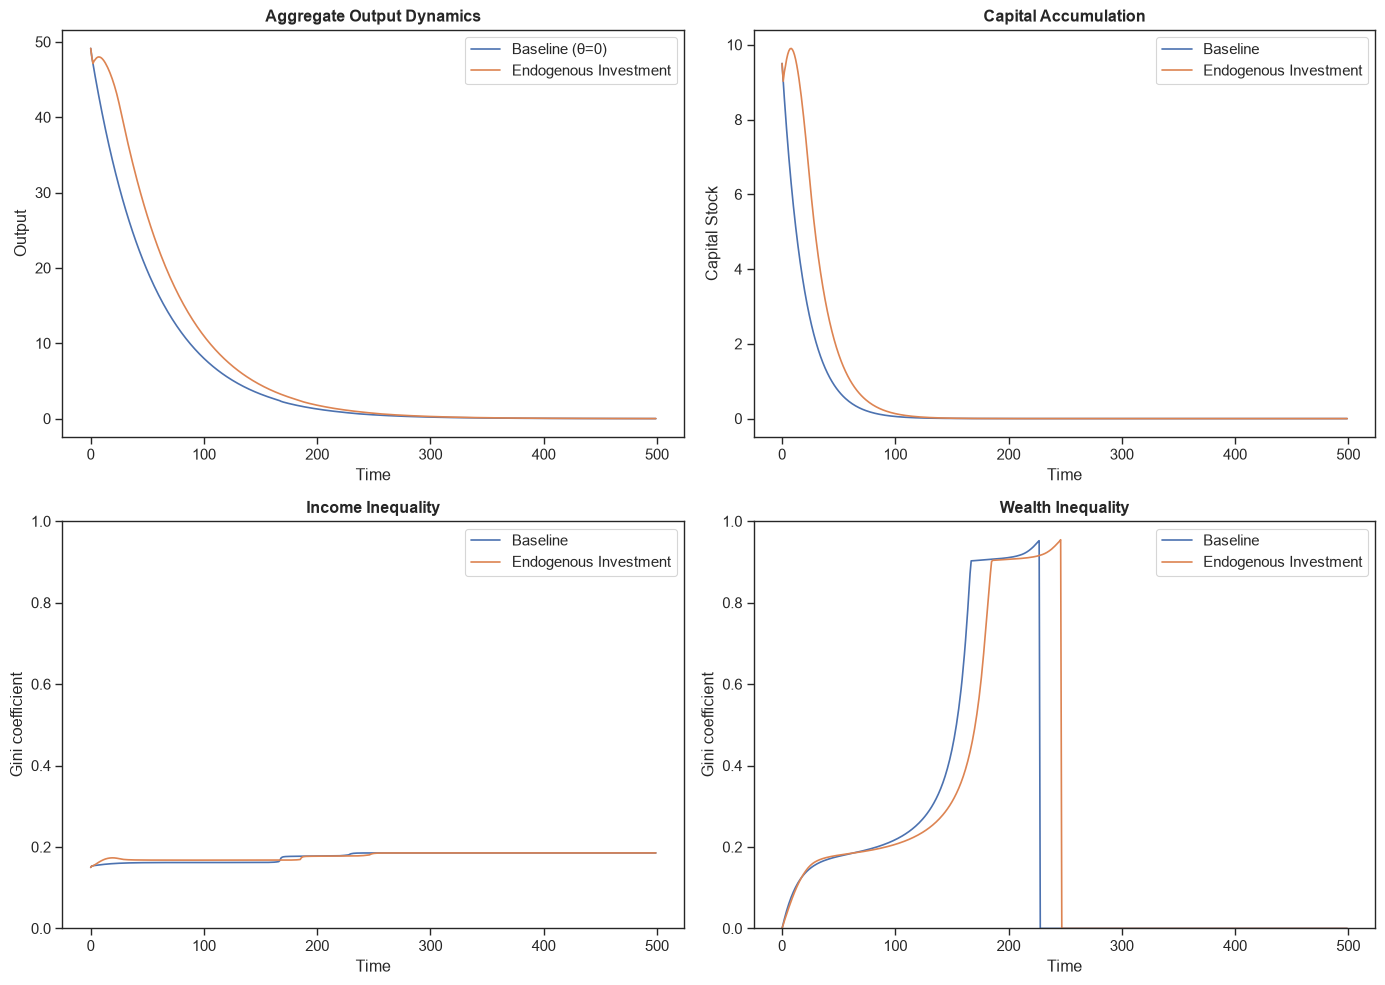

In [1]:
import sys
import os

# Add source folder
sys.path.append(
    os.path.abspath(
        'C:\\Users\\recursivechaos\\Documents\\ABM\\src'
    )
)


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from model import MacroModel



# ============================================================
# Simulation Parameters
# ============================================================

STEPS = 500
SEEDS = 50


BASELINE_THETA = 0.0
INVESTMENT_THETA = 0.3



# ============================================================
# Experiment Runner
# ============================================================

def run_experiment(theta):

    results = []


    for seed in range(SEEDS):

        model = MacroModel(

            num_firms=10,

            num_households=100,

            pct_capitalists=0.10,


            # Firm parameters
            markup=0.2,
            beta=1.0,
            alpha=0.35,
            delta=0.05,


            # Consumption
            c0=0.01,
            c1=0.6,
            wealth_effect=0.1,


            # Investment
            theta=theta,
            investment_sensitivity=1.0,
            target_utilization=0.8,


            extra=0.1,


            seed=seed
        )


        for step in range(STEPS):

            model.step()


        df = (
            model
            .datacollector
            .get_model_vars_dataframe()
        )


        df["Seed"] = seed

        results.append(df)


    return pd.concat(results)



# ============================================================
# Run Baseline and Investment Economies
# ============================================================


baseline = run_experiment(
    BASELINE_THETA
)


investment = run_experiment(
    INVESTMENT_THETA
)



# ============================================================
# Average Dynamics
# ============================================================


baseline_mean = (
    baseline
    .groupby(baseline.index)
    .mean(numeric_only=True)
)


investment_mean = (
    investment
    .groupby(investment.index)
    .mean(numeric_only=True)
)



# ============================================================
# Visualization
# ============================================================


sns.set_theme(
    style="ticks",
    context="paper",
    font_scale=1.2
)



fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)



# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

ax = axes[0,0]

ax.plot(
    baseline_mean.index,
    baseline_mean["Output"],
    label="Baseline (θ=0)"
)


ax.plot(
    investment_mean.index,
    investment_mean["Output"],
    label="Endogenous Investment"
)


ax.set_title(
    "Aggregate Output Dynamics",
    weight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("Output")

ax.legend()



# ------------------------------------------------------------
# Capital
# ------------------------------------------------------------

ax = axes[0,1]


ax.plot(
    baseline_mean.index,
    baseline_mean["Total_Capital"],
    label="Baseline"
)


ax.plot(
    investment_mean.index,
    investment_mean["Total_Capital"],
    label="Endogenous Investment"
)


ax.set_title(
    "Capital Accumulation",
    weight="bold"
)


ax.set_xlabel("Time")
ax.set_ylabel("Capital Stock")

ax.legend()



# ------------------------------------------------------------
# Income inequality
# ------------------------------------------------------------

ax = axes[1,0]


ax.plot(
    baseline_mean.index,
    baseline_mean["Income_Gini"],
    label="Baseline"
)


ax.plot(
    investment_mean.index,
    investment_mean["Income_Gini"],
    label="Endogenous Investment"
)


ax.set_title(
    "Income Inequality",
    weight="bold"
)


ax.set_xlabel("Time")
ax.set_ylabel("Gini coefficient")

ax.set_ylim(0,1)

ax.legend()



# ------------------------------------------------------------
# Wealth inequality
# ------------------------------------------------------------

ax = axes[1,1]


ax.plot(
    baseline_mean.index,
    baseline_mean["Wealth_Gini"],
    label="Baseline"
)


ax.plot(
    investment_mean.index,
    investment_mean["Wealth_Gini"],
    label="Endogenous Investment"
)


ax.set_title(
    "Wealth Inequality",
    weight="bold"
)


ax.set_xlabel("Time")
ax.set_ylabel("Gini coefficient")

ax.set_ylim(0,1)

ax.legend()



plt.tight_layout()



# Save figure

output_path = (
    'C:\\Users\\recursivechaos\\Documents\\ABM\\macro_results.png'
)


plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()